In [17]:
import os
import random
import time
from pathlib import Path
from tqdm import tqdm
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms, models

import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from jpeg_aug import RandomJPEGCompression

In [2]:
# Checking Device/confirming it works with CUDA

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

x = torch.randn(10000, 10000, device=device)
print("Computation successful on", device)

Using device: cuda
Computation successful on cuda


In [3]:
# Helper Functions

def subset_dataset(dataset, percent, seed=6050):
    if percent >= 1.0:
        return dataset
    
    random.seed(seed)
    subset_size = int(len(dataset) * percent)
    indices = random.sample(range(len(dataset)), subset_size)
    return Subset(dataset, indices)

def plot_loss_and_acc(track_loss, track_train_acc, track_val_acc):
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.plot(track_train_acc, label="Train")
    plt.plot(track_val_acc, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(track_loss, label="Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()



In [4]:
# CONFIGURATION

data_root = Path(r"/sfs/weka/scratch/uts4gf/ID_of_AI_Images/DS6050_Ai_Detection")  # adjust as needed
train_dir = data_root / "train"
val_dir = data_root / "validation"

batch_size = 32
num_workers = 4
num_epochs = 5
learning_rate = 1e-4
train_percent = 0.5  # train/validate on 50% of data

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [7]:
# DATA TRANSFORMS

transform = transforms.Compose([
    transforms.Resize((256, 256)),  # Resize for ResNet
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    RandomJPEGCompression(quality_range=(30, 95)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

'''
resize will resize the image to 256x256
randomcrop will random crop a 224x224 image from the 256x256 image
randomhorizontalflip will randomly flip the image horizontally

toTensor will convert the image to a tensor
normalize will normalize the image, values are picked from imagenet mean and std, which the resnet50 is pretrained on

'''

'\nresize will resize the image to 256x256\nrandomcrop will random crop a 224x224 image from the 256x256 image\nrandomhorizontalflip will randomly flip the image horizontally\n\ntoTensor will convert the image to a tensor\nnormalize will normalize the image, values are picked from imagenet mean and std, which the resnet50 is pretrained on\n\n'

In [8]:
# dataloader loads alphabetically, so we need to swap labels + adding FFT
class FFTImageFolder(datasets.ImageFolder):
    def __getitem__(self, index):
        img, label = super().__getitem__(index)
        
        # Swap label: real=0, fake=1
        label = 1 - label
        
        fft = torch.fft.fft2(img, dim=(-2, -1))
        fft = torch.fft.fftshift(fft) 
        
        fft_mag = torch.abs(fft)
        
        fft_mag = torch.log1p(fft_mag)

        fft_mag = (fft_mag - fft_mag.mean()) / (fft_mag.std() + 1e-6)

        # Concatenate into a 6-channel tensor
        img_fft = torch.cat([img, fft_mag], dim=0)

        return img_fft, label

In [9]:
# LOAD DATASETS

# train_dataset = CustomImageFolder(root=str(train_dir), transform=transform)
# val_dataset = CustomImageFolder(root=str(val_dir), transform=transform)

train_dataset = FFTImageFolder(root=str(train_dir), transform=transform)
val_dataset   = FFTImageFolder(root=str(val_dir), transform=transform)

print("Original class mapping:", train_dataset.class_to_idx)  # still 'fake':0, 'real':1

# train_dataset = subset_dataset(train_dataset, train_percent)
# val_dataset = subset_dataset(val_dataset, train_percent)

#DATALOADERS
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Training on {len(train_dataset)} images, validating on {len(val_dataset)} images.")

Original class mapping: {'fake': 0, 'real': 1}
Training on 115200 images, validating on 28340 images.


In [10]:
# --- Paths to your fake CSVs (adjust names/paths as needed) ---
train_fake_csv_path = r'../temporal_validation/fake_train_temporal_splits.csv'
val_fake_csv_path   = r'../temporal_validation/fake_validation_temporal_splits.csv'

train_fake_df = pd.read_csv(train_fake_csv_path)
val_fake_df   = pd.read_csv(val_fake_csv_path)

# Ensure filename column is just the basename (in case it has paths)
train_fake_df["filename"] = train_fake_df["filename"].apply(os.path.basename)
val_fake_df["filename"]   = val_fake_df["filename"].apply(os.path.basename)

# Map: filename -> window
train_file_to_window = dict(zip(train_fake_df["filename"], train_fake_df["w_split"]))
val_file_to_window   = dict(zip(val_fake_df["filename"],   val_fake_df["w_split"]))

# Determine max window index
max_train_w = train_fake_df["w_split"].max()
max_val_w   = val_fake_df["w_split"].max()
max_w       = int(max(max_train_w, max_val_w))

print(f"Max window index detected: {max_w}")

Max window index detected: 8


In [11]:
# --- Per-window fake indices for train/val ---
train_fake_indices_by_w = {w: [] for w in range(max_w + 1)}
val_fake_indices_by_w   = {w: [] for w in range(max_w + 1)}

# --- Real indices (used at all steps) ---
train_real_indices = []
val_real_indices   = []

FAKE_CLASS = train_dataset.class_to_idx["fake"]  # 0
REAL_CLASS = train_dataset.class_to_idx["real"]  # 1

# Build train indices
for idx, (path, cls) in enumerate(train_dataset.samples):
    fname = os.path.basename(path)
    if cls == REAL_CLASS:
        train_real_indices.append(idx)
    elif cls == FAKE_CLASS:
        if fname in train_file_to_window:
            w = int(train_file_to_window[fname])
            train_fake_indices_by_w[w].append(idx)
        else:
            # Optional: warn if some fake images don't have a window
            print(f"[WARN] Train fake missing from CSV: {fname}")

# Build val indices
for idx, (path, cls) in enumerate(val_dataset.samples):
    fname = os.path.basename(path)
    if cls == REAL_CLASS:
        val_real_indices.append(idx)
    elif cls == FAKE_CLASS:
        if fname in val_file_to_window:
            w = int(val_file_to_window[fname])
            val_fake_indices_by_w[w].append(idx)
        else:
            print(f"[WARN] Val fake missing from CSV: {fname}")

print("Train real:", len(train_real_indices))
for w in range(max_w + 1):
    print(f"Train fake w{w}: {len(train_fake_indices_by_w[w])}")

print("Val real:", len(val_real_indices))
for w in range(max_w + 1):
    print(f"Val fake w{w}: {len(val_fake_indices_by_w[w])}")


Train real: 57600
Train fake w0: 6364
Train fake w1: 6455
Train fake w2: 6501
Train fake w3: 6385
Train fake w4: 6268
Train fake w5: 6411
Train fake w6: 6370
Train fake w7: 6387
Train fake w8: 6459
Val real: 14170
Val fake w0: 1545
Val fake w1: 1604
Val fake w2: 1524
Val fake w3: 1570
Val fake w4: 1600
Val fake w5: 1594
Val fake w6: 1559
Val fake w7: 1587
Val fake w8: 1587


In [12]:
def make_loader_for_windows(
    dataset,
    real_indices,
    fake_indices_by_w,
    windows,
    batch_size,
    shuffle,
    num_workers=0
):
    all_indices = list(real_indices)
    for w in windows:
        all_indices.extend(fake_indices_by_w[w])
    subset = Subset(dataset, all_indices)
    loader = DataLoader(subset, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers)
    return loader, len(all_indices)


In [13]:
subset = train_dataset

for idx in range(10):
    if isinstance(subset, torch.utils.data.Subset):
        actual_idx = subset.indices[idx]
        img, label = subset[idx]
        path = subset.dataset.imgs[actual_idx][0]
    else:
        img, label = subset[idx]
        path = subset.imgs[idx][0]

    print(f"{path} --> Label: {label}")

/sfs/weka/scratch/uts4gf/ID_of_AI_Images/DS6050_Ai_Detection/train/fake/train\fake\000001.png --> Label: 1
/sfs/weka/scratch/uts4gf/ID_of_AI_Images/DS6050_Ai_Detection/train/fake/train\fake\000002.png --> Label: 1
/sfs/weka/scratch/uts4gf/ID_of_AI_Images/DS6050_Ai_Detection/train/fake/train\fake\000003.png --> Label: 1
/sfs/weka/scratch/uts4gf/ID_of_AI_Images/DS6050_Ai_Detection/train/fake/train\fake\000004.png --> Label: 1
/sfs/weka/scratch/uts4gf/ID_of_AI_Images/DS6050_Ai_Detection/train/fake/train\fake\000006.png --> Label: 1
/sfs/weka/scratch/uts4gf/ID_of_AI_Images/DS6050_Ai_Detection/train/fake/train\fake\000008.png --> Label: 1
/sfs/weka/scratch/uts4gf/ID_of_AI_Images/DS6050_Ai_Detection/train/fake/train\fake\000012.png --> Label: 1
/sfs/weka/scratch/uts4gf/ID_of_AI_Images/DS6050_Ai_Detection/train/fake/train\fake\000013.png --> Label: 1
/sfs/weka/scratch/uts4gf/ID_of_AI_Images/DS6050_Ai_Detection/train/fake/train\fake\000014.png --> Label: 1
/sfs/weka/scratch/uts4gf/ID_of_AI_Ima

In [14]:
# MODEL SETUP (ResNet50)

model = models.resnet50(weights=True)
num_ftrs = model.fc.in_features

model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),   # hidden layer
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, 2)           # final output
)

# updating model to handle FFT, swiching CNN to 6
old_conv = model.conv1
model.conv1 = nn.Conv2d(
    in_channels=6,
    out_channels=old_conv.out_channels,
    kernel_size=old_conv.kernel_size,
    stride=old_conv.stride,
    padding=old_conv.padding,
    bias=False
)

# initialize the extra channels for CNN
with torch.no_grad():
    model.conv1.weight[:, :3] = old_conv.weight  # keep pretrained RGB filters
    model.conv1.weight[:, 3:] = old_conv.weight.mean(dim=1, keepdim=True)  # duplicate as “gray”


model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # adding label smoothing for better generalization

optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4) # adding L2 regularization

/scratch/uts4gf/.conda/envs/id_ai/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [15]:
def show_jpeg_transform_effect(dataset, index, jpeg_transform):
    # Load image according to dataset structure
    if isinstance(dataset, torch.utils.data.Subset):
        original_idx = dataset.indices[index]
        path = dataset.dataset.samples[original_idx][0]
        pil_img = Image.open(path).convert("RGB")
        label = dataset[ index ][1]
    else:
        path = dataset.samples[index][0]
        pil_img = Image.open(path).convert("RGB")
        label = dataset[index][1]
        
    # Apply your RandomJPEGCompression transform
    compressed_img = jpeg_transform(pil_img)

    # Plot original vs. compressed
    fig, axs = plt.subplots(1, 2, figsize=(8, 4))

    axs[0].imshow(pil_img)
    axs[0].set_title(f"Original\n{os.path.basename(path)}")
    axs[0].axis("off")

    axs[1].imshow(compressed_img)
    axs[1].set_title(f"JPEG Transform Applied\nClass={label}")
    axs[1].axis("off")

    plt.tight_layout()
    plt.show()

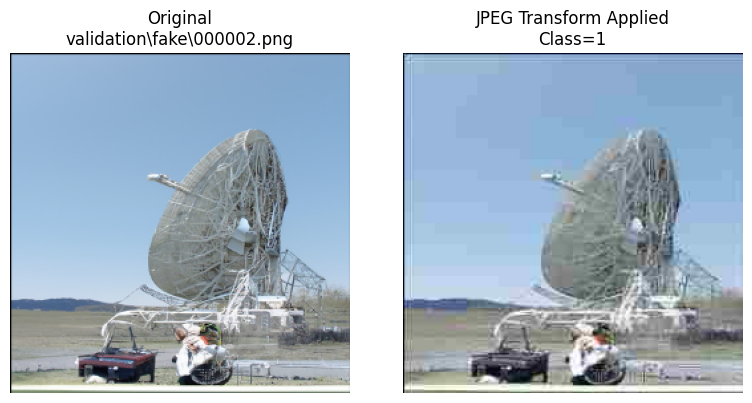

In [21]:
jpeg_aug = RandomJPEGCompression(quality_range=(5, 60))
show_jpeg_transform_effect(val_dataset, 1, jpeg_aug)

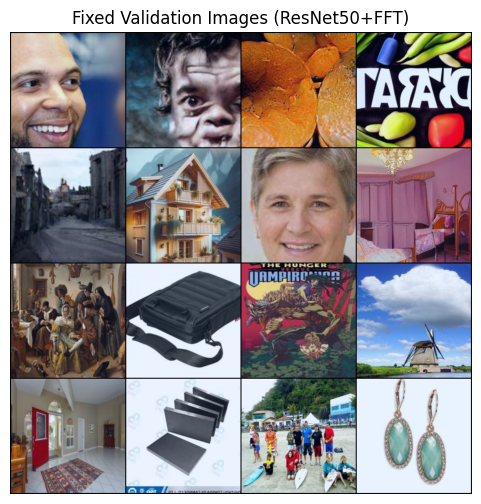

Fake: validation\fake\027892.png
Fake: validation\fake\000658.png
Fake: validation\fake\013439.png
Fake: validation\fake\001649.png
Fake: validation\fake\001018.png
Fake: validation\fake\010257.png
Fake: validation\fake\010900.png
Fake: validation\fake\018497.png
Real: validation\real\0025612.png
Real: validation\real\0023795.png
Real: validation\real\0003072.png
Real: validation\real\0025824.png
Real: validation\real\0018740.png
Real: validation\real\0003979.png
Real: validation\real\000000274460.jpg
Real: validation\real\0024994.png


In [22]:
# SEED = 42
# torch.manual_seed(SEED)
# np.random.seed(SEED)
# random.seed(SEED)

grid_size = 4
num_images = grid_size * grid_size

if isinstance(val_dataset, torch.utils.data.Subset):
    subset = val_dataset
    base = val_dataset.dataset

    all_indices = subset.indices
    all_paths  = [base.samples[i][0] for i in all_indices]
    all_labels = [base.samples[i][1] for i in all_indices]

else:
    all_paths  = [p for p, l in val_dataset.samples]
    all_labels = [l for p, l in val_dataset.samples]

labels_tensor = torch.tensor(all_labels)

real_indices = (labels_tensor == 0).nonzero(as_tuple=True)[0]
fake_indices = (labels_tensor == 1).nonzero(as_tuple=True)[0]

half_num = num_images // 2
real_sample = real_indices[torch.randperm(len(real_indices))[:half_num]]
fake_sample = fake_indices[torch.randperm(len(fake_indices))[:half_num]]

subset_indices = torch.cat([real_sample, fake_sample])

if isinstance(val_dataset, torch.utils.data.Subset):
    base = val_dataset.dataset
    original_indices = [all_indices[i.item()] for i in subset_indices]

    fixed_images = torch.stack([base[i][0] for i in original_indices]).to(device)
    fixed_labels = torch.tensor([base[i][1] for i in original_indices]).to(device)
    fixed_paths  = [all_paths[i] for i in subset_indices]

else:
    fixed_images = torch.stack([val_dataset[i][0] for i in subset_indices]).to(device)
    fixed_labels = torch.tensor([val_dataset[i][1] for i in subset_indices]).to(device)
    fixed_paths  = [all_paths[i] for i in subset_indices]

#UPDATE FOR FFT
fixed_rgb = fixed_images[:, :3, :, :]   # shape (N, 3, H, W)

grid_img = make_grid(fixed_rgb.cpu(), nrow=grid_size, normalize=True)
plt.figure(figsize=(6,6))
plt.imshow(np.transpose(grid_img.numpy(), (1,2,0)))
plt.axis("off")
plt.title("Fixed Validation Images (ResNet50+FFT)")
plt.show()

for path, lbl in zip(fixed_paths, fixed_labels):
    print(f"{'Real' if lbl==0 else 'Fake'}: {os.path.basename(path)}")


In [24]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    train_pbar = tqdm(train_loader, desc="Training", unit="batch")
    for images, labels in train_pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        avg_loss = running_loss / (len(train_loader) if len(train_loader) > 0 else 1)
        train_acc = 100.0 * correct / total

        train_pbar.set_postfix({
            "Loss": f"{avg_loss:.4f}",
            "Train Acc": f"{train_acc:.2f}%"
        })

    avg_loss = running_loss / (len(train_loader) if len(train_loader) > 0 else 1)
    train_acc = 100.0 * correct / total if total > 0 else 0.0
    return avg_loss, train_acc


def eval_accuracy(model, loader, device, desc="Evaluating"):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        pbar = tqdm(loader, desc=desc, unit="batch", leave=False)
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    acc = 100.0 * correct / total if total > 0 else 0.0
    return acc


In [26]:
def sliding_window_training(
    model,
    criterion,
    optimizer,
    train_dataset,
    val_dataset,
    train_real_indices,
    train_fake_indices_by_w,
    val_real_indices,
    val_fake_indices_by_w,
    max_w,
    num_epochs_per_step,
    batch_size,
    device,
    num_workers=0
):
    history = []
    start_time = time.time()

    # --- Best model tracking ---
    best_val_acc = 0.0
    best_state = None

    for k in range(0, max_w):  
        print("\n" + "="*70)
        print(f"🔷 Sliding step {k}: train on w[0..{k}], validate on w{ k+1 }")
        print("="*70)

        past_windows = list(range(0, k+1))
        next_window  = k + 1
        all_up_to_next = list(range(0, max_w+1))

        # --- Build loaders ---
        train_loader, n_train = make_loader_for_windows(
            train_dataset,
            train_real_indices,
            train_fake_indices_by_w,
            past_windows,
            batch_size=batch_size,
            shuffle=True,
            num_workers=num_workers
        )

        val_past_loader, n_val_past = make_loader_for_windows(
            val_dataset,
            val_real_indices,
            val_fake_indices_by_w,
            past_windows,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers
        )

        val_next_loader, n_val_next = make_loader_for_windows(
            val_dataset,
            val_real_indices,
            val_fake_indices_by_w,
            [next_window],
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers
        )

        val_all_loader, n_val_all = make_loader_for_windows(
            val_dataset,
            val_real_indices,
            val_fake_indices_by_w,
            all_up_to_next,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers
        )

        print(f"Train: {n_train} samples (Real + Fake windows {past_windows})")
        print(f"Val past: {n_val_past} samples (windows {past_windows})")
        print(f"Val next: {n_val_next} samples (window {next_window})")
        print(f"Val all:  {n_val_all} samples (windows {all_up_to_next})")

        # --- Train for num_epochs_per_step ---
        for epoch in range(num_epochs_per_step):
            epoch_start_time = time.time()
            print(f"\n[Step {k}] Epoch {epoch+1}/{num_epochs_per_step}")

            train_loss, train_acc = train_one_epoch(
                model, train_loader, criterion, optimizer, device
            )

            # Three validations
            acc_past = eval_accuracy(model, val_past_loader, device, desc="Val past")
            acc_next = eval_accuracy(model, val_next_loader, device, desc="Val next")
            acc_all  = eval_accuracy(model, val_all_loader,  device, desc="Val all")

            # --- Best model check (using ValAll) ---
            if acc_all > best_val_acc:
                best_val_acc = acc_all
                best_state = {k: v.cpu() for k, v in model.state_dict().items()}
                print(f"🌟 New best model! ValAll = {acc_all:.2f}%")

            print(
                f"[Step {k} | Epoch {epoch+1}] "
                f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
                f"ValPast: {acc_past:.2f}% | ValNext: {acc_next:.2f}% | ValAll: {acc_all:.2f}%"
            )

            history.append({
                "step": k,
                "epoch": epoch + 1,
                "train_loss": train_loss,
                "train_acc": train_acc,
                "val_past_acc": acc_past,
                "val_next_acc": acc_next,
                "val_all_acc": acc_all
            })

            total_epoch_minutes = (time.time() - epoch_start_time) / 60.0
            print(f"Total Epoch time: {total_epoch_minutes:.2f} minutes")

    total_minutes = (time.time() - start_time) / 60.0
    print(f"\nSliding-window training complete in {total_minutes:.2f} minutes.")
    print(f"🏆 Best ValAll accuracy: {best_val_acc:.2f}%")

    return history, best_state


## Temporal Run 11/25 1500

In [ ]:
num_epochs_per_step = 3

history, best_state = sliding_window_training(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    train_real_indices=train_real_indices,
    train_fake_indices_by_w=train_fake_indices_by_w,
    val_real_indices=val_real_indices,
    val_fake_indices_by_w=val_fake_indices_by_w,
    max_w=max_w,
    num_epochs_per_step=num_epochs_per_step,
    batch_size=batch_size,
    device=device,
    num_workers=0
)

torch.save(best_state, "best_resnet50_FFT_sliding.pth")
print("Saved best model to best_resnet50_sliding.pth")


🔷 Sliding step 0: train on w[0..0], validate on w1
Train: 63964 samples (Real + Fake windows [0])
Val past: 15715 samples (windows [0])
Val next: 15774 samples (window 1)
Val all:  28340 samples (windows [0, 1, 2, 3, 4, 5, 6, 7, 8])

[Step 0] Epoch 1/3


Training: 100%|██████████| 1999/1999 [13:38<00:00,  2.44batch/s, Loss=0.2825, Train Acc=95.72%]
                                                              

🌟 New best model! ValAll = 68.12%
[Step 0 | Epoch 1] Train Loss: 0.2825 | Train Acc: 95.72% | ValPast: 94.79% | ValNext: 91.18% | ValAll: 68.12%
Total Epoch time: 26.24 minutes

[Step 0] Epoch 2/3


Training: 100%|██████████| 1999/1999 [12:49<00:00,  2.60batch/s, Loss=0.2622, Train Acc=96.60%]
                                                              

[Step 0 | Epoch 2] Train Loss: 0.2622 | Train Acc: 96.60% | ValPast: 96.81% | ValNext: 93.50% | ValAll: 64.71%
Total Epoch time: 24.87 minutes

[Step 0] Epoch 3/3


...

Training: 100%|██████████| 3000/3000 [16:23<00:00,  3.05batch/s, Loss=0.3300, Train Acc=91.98%]
                                                              

[Step 5 | Epoch 1] Train Loss: 0.3300 | Train Acc: 91.98% | ValPast: 92.13% | ValNext: 91.79% | ValAll: 82.10%
Total Epoch time: 29.15 minutes

[Step 5] Epoch 2/3


Training: 100%|██████████| 3000/3000 [16:20<00:00,  3.06batch/s, Loss=0.3237, Train Acc=92.35%]
                                                              

[Step 5 | Epoch 2] Train Loss: 0.3237 | Train Acc: 92.35% | ValPast: 91.72% | ValNext: 92.22% | ValAll: 82.16%
Total Epoch time: 29.22 minutes

[Step 5] Epoch 3/3


Training:  11%|█▏        | 342/3000 [01:51<14:07,  3.14batch/s, Loss=0.0358, Train Acc=92.81%]

In [ ]:
hist_df = pd.DataFrame(history)
print(hist_df.head())

In [ ]:
hist_df['val_all_acc'].plot()

In [ ]:
hist_df['val_next_acc'].plot()

In [ ]:
hist_df['train_loss'].plot()